Exact value of the integral = 0.5000000000

Chosen proposal density for importance sampling:
p(x) = 2 / (1 + x)^2,  0 <= x <= 1
Inverse CDF transform:
x = u / (2 - u), where u ~ Uniform(0, 1)

Comparison of methods:
N        | simple MC estimate | simple MC error | IS estimate     | IS error
     100 |       0.4838364642 |    0.0161635358 |    0.5000000000 | 0.0000000000
    1000 |       0.4993453463 |    0.0006546537 |    0.5000000000 | 0.0000000000
   10000 |       0.4987662140 |    0.0012337860 |    0.5000000000 | 0.0000000000
  100000 |       0.5001358816 |    0.0001358816 |    0.5000000000 | 0.0000000000


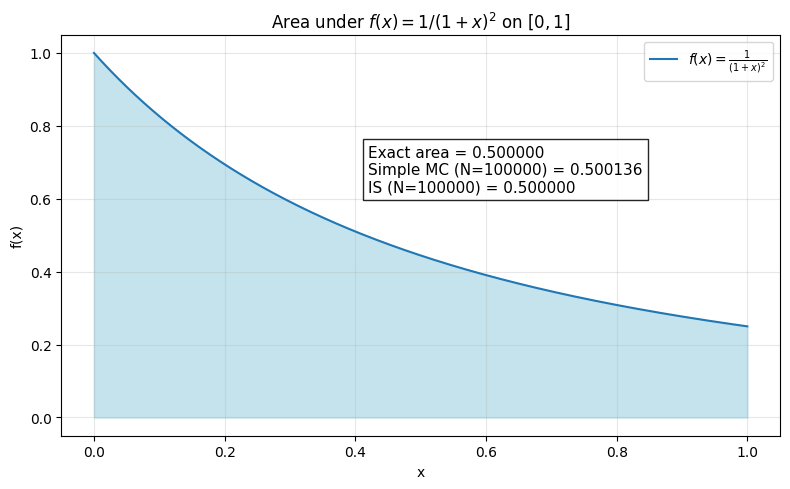

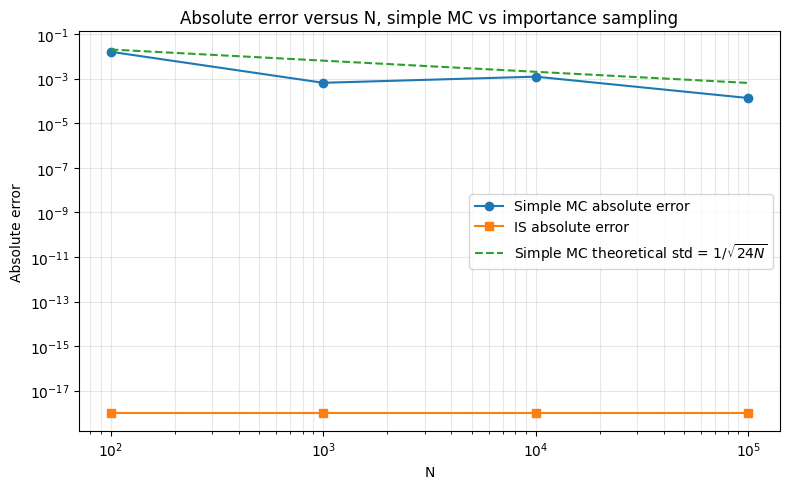

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Define the random seed used to make the experiments reproducible.
SEED = 1

# Define the sample sizes used to compare the methods.
N_VALUES = np.array([10**2, 10**3, 10**4, 10**5], dtype=int)

# Define the number of points used to draw smooth curves in the plots.
PLOT_POINTS = 1000


def exact_integral() -> float:
    """Return the exact value of the integral int_0^1 1 / (1 + x)^2 dx.

    Returns:
        Exact analytical value of the integral.
    """
    # Return the closed-form result obtained analytically.
    return 0.5


def f(x: np.ndarray) -> np.ndarray:
    """Evaluate the target integrand f(x) = 1 / (1 + x)^2.

    Args:
        x: Points where the integrand will be evaluated.

    Returns:
        Values of the integrand at the input points.
    """
    # Evaluate the target integrand.
    return 1.0 / (1.0 + x) ** 2


def p(x: np.ndarray) -> np.ndarray:
    """Evaluate the proposal PDF p(x) = 2 / (1 + x)^2 on [0, 1].

    Args:
        x: Points where the proposal PDF will be evaluated.

    Returns:
        Values of the proposal PDF at the input points.
    """
    # Evaluate the chosen importance sampling density.
    return 2.0 / (1.0 + x) ** 2


def inverse_cdf_p(u: np.ndarray) -> np.ndarray:
    """Transform uniform samples into samples distributed according to p(x).

    The proposal CDF is:
        P(x) = 2x / (1 + x)

    Solving U = P(x) for x gives:
        x = U / (2 - U)

    Args:
        u: Uniform random samples in [0, 1].

    Returns:
        Samples distributed according to p(x).
    """
    # Apply the inverse CDF derived analytically.
    return u / (2.0 - u)


def simple_monte_carlo_estimate(n: int, seed: int) -> float:
    """Estimate the integral using standard Monte Carlo with uniform sampling.

    Args:
        n: Number of Monte Carlo samples.
        seed: Seed for the random number generator.

    Returns:
        Standard Monte Carlo estimate of the integral.
    """
    # Create a reproducible random number generator.
    rng = np.random.default_rng(seed)

    # Generate n uniform samples in the interval [0, 1].
    x = rng.uniform(0.0, 1.0, n)

    # Evaluate the integrand at the generated samples.
    fx = f(x)

    # Return the Monte Carlo average.
    return np.mean(fx)


def importance_sampling_estimate(n: int, seed: int) -> float:
    """Estimate the integral using importance sampling.

    Args:
        n: Number of Monte Carlo samples.
        seed: Seed for the random number generator.

    Returns:
        Importance sampling estimate of the integral.
    """
    # Create a reproducible random number generator.
    rng = np.random.default_rng(seed)

    # Generate n uniform samples in the interval [0, 1].
    u = rng.uniform(0.0, 1.0, n)

    # Transform the uniform samples into samples distributed according to p(x).
    x = inverse_cdf_p(u)

    # Evaluate the target integrand at the generated samples.
    fx = f(x)

    # Evaluate the proposal PDF at the generated samples.
    px = p(x)

    # Compute the weighted samples f(x) / p(x).
    weighted_samples = fx / px

    # Return the Monte Carlo average of the weighted samples.
    return np.mean(weighted_samples)


def theoretical_simple_mc_variance(n: int) -> float:
    """Return the theoretical variance of the standard Monte Carlo estimator.

    For this exercise:
        Var(I_hat_simple) = 1 / (24N)

    Args:
        n: Number of Monte Carlo samples.

    Returns:
        Theoretical variance of the standard Monte Carlo estimator.
    """
    # Return the analytical variance derived by hand.
    return 1.0 / (24.0 * n)


def main() -> None:
    """Run the full analytical comparison and both Monte Carlo simulations."""
    # Compute the exact value of the integral.
    exact_value = exact_integral()

    # Print the exact analytical result before the simulations.
    print(f"Exact value of the integral = {exact_value:.10f}")
    print()

    # Print the chosen proposal density.
    print("Chosen proposal density for importance sampling:")
    print("p(x) = 2 / (1 + x)^2,  0 <= x <= 1")
    print("Inverse CDF transform:")
    print("x = u / (2 - u), where u ~ Uniform(0, 1)")
    print()

    # Create empty lists to store the standard Monte Carlo estimates.
    simple_estimates = []

    # Create empty lists to store the importance sampling estimates.
    is_estimates = []

    # Create empty lists to store the standard Monte Carlo absolute errors.
    simple_errors = []

    # Create empty lists to store the importance sampling absolute errors.
    is_errors = []

    # Print a header for the numerical comparison.
    print("Comparison of methods:")
    print("N        | simple MC estimate | simple MC error | IS estimate     | IS error")

    # Loop over all requested sample sizes.
    for n in N_VALUES:
        # Compute the standard Monte Carlo estimate for the current sample size.
        simple_estimate = simple_monte_carlo_estimate(n=n, seed=SEED + int(n))

        # Compute the importance sampling estimate for the current sample size.
        is_estimate = importance_sampling_estimate(n=n, seed=SEED + int(n))

        # Compute the absolute error of the standard Monte Carlo estimate.
        simple_error = abs(simple_estimate - exact_value)

        # Compute the absolute error of the importance sampling estimate.
        is_error = abs(is_estimate - exact_value)

        # Store the standard Monte Carlo estimate.
        simple_estimates.append(simple_estimate)

        # Store the importance sampling estimate.
        is_estimates.append(is_estimate)

        # Store the standard Monte Carlo absolute error.
        simple_errors.append(simple_error)

        # Store the importance sampling absolute error.
        is_errors.append(is_error)

        # Print the numerical results for the current sample size.
        print(
            f"{n:8d} | {simple_estimate:18.10f} | {simple_error:15.10f} | "
            f"{is_estimate:15.10f} | {is_error:8.10f}"
        )

    # Convert the lists of estimates into NumPy arrays.
    simple_estimates = np.array(simple_estimates)

    # Convert the importance sampling estimates into a NumPy array.
    is_estimates = np.array(is_estimates)

    # Convert the simple Monte Carlo errors into a NumPy array.
    simple_errors = np.array(simple_errors)

    # Convert the importance sampling errors into a NumPy array.
    is_errors = np.array(is_errors)

    # Compute the theoretical standard deviation of the simple Monte Carlo estimator.
    theoretical_simple_std = np.sqrt(np.array([theoretical_simple_mc_variance(n) for n in N_VALUES]))

    # Create a dense grid of x values for plotting the integrand.
    x_plot = np.linspace(0.0, 1.0, PLOT_POINTS)

    # Evaluate the integrand on the dense plotting grid.
    y_plot = f(x_plot)

    # Create the first figure for the area under the curve.
    plt.figure(figsize=(8, 5))

    # Plot the target integrand.
    plt.plot(x_plot, y_plot, label=r"$f(x)=\frac{1}{(1+x)^2}$")

    # Fill the area under the curve to visually represent the integral.
    plt.fill_between(x_plot, y_plot, color="lightblue", alpha=0.7)

    # Add a text box showing the exact area and the last estimates.
    plt.text(
        0.42,
        0.62,
        f"Exact area = {exact_value:.6f}\n"
        f"Simple MC (N={N_VALUES[-1]}) = {simple_estimates[-1]:.6f}\n"
        f"IS (N={N_VALUES[-1]}) = {is_estimates[-1]:.6f}",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.85),
    )

    # Label the horizontal axis.
    plt.xlabel("x")

    # Label the vertical axis.
    plt.ylabel("f(x)")

    # Add a title to the first figure.
    plt.title(r"Area under $f(x)=1/(1+x)^2$ on $[0,1]$")

    # Add a grid for readability.
    plt.grid(True, alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout of the first figure.
    plt.tight_layout()

    # Create the second figure for the absolute error comparison.
    plt.figure(figsize=(8, 5))

    # Plot the simple Monte Carlo absolute error on log-log axes.
    plt.loglog(N_VALUES, simple_errors, marker="o", label="Simple MC absolute error")

    # Plot the importance sampling absolute error on log-log axes.
    plt.loglog(N_VALUES, is_errors + 1e-18, marker="s", label="IS absolute error")

    # Plot the theoretical standard deviation trend of the simple MC estimator.
    plt.loglog(
        N_VALUES,
        theoretical_simple_std,
        linestyle="--",
        label=r"Simple MC theoretical std = $1/\sqrt{24N}$",
    )

    # Label the horizontal axis.
    plt.xlabel("N")

    # Label the vertical axis.
    plt.ylabel("Absolute error")

    # Add a title to the second figure.
    plt.title("Absolute error versus N, simple MC vs importance sampling")

    # Add a grid for readability.
    plt.grid(True, which="both", alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout of the second figure.
    plt.tight_layout()

    # Display all generated figures.
    plt.show()


# Run the script when the file is executed directly.
if __name__ == "__main__":
    # Execute the main routine.
    main()